# Database-only structural robustness checks

This notebook uses only the finite-element (FE) labels supplied in the challenge database.  It never uses an optimizer's own surrogate to declare a candidate robust.

The database contains repeated **planform + flight** groups with alternative internal structures. Those groups support observed structural comparisons at fixed external controls. They do *not* support causal planform perturbations at fixed structure and flight, nor do they directly validate newly generated continuous optimizer candidates.

A supported result means there are enough matched, FE-labelled pairs in the database. It is screening evidence—not a substitute for an independent structural solve.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
DATA_PATH = ROOT / 'data' / 'bwb_structures_dataset.csv'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

STRESS_LIMIT_MPA = 335.0
ARTIFACT_STRESS_MPA = 1e4
OTHER_VARIABLE_CALIPER = 0.10  # fraction of each documented design range
MIN_MATCHED_PAIRS = 50
DATA_BOUND_TOLERANCE = 1e-5  # source data is rounded slightly beyond one documented bound

PLANFORM_COLUMNS = ['C2/C1', 'C3/C1', 'C4/C1', 'B1/C1', 'B2/C1', 'B3/C1', 'X3/C1', 'S1', 'S3', 'C1']
FLIGHT_COLUMNS = ['Altitude', 'KCAS', 'AOA']
STRUCTURAL_COLUMNS = ['Skin Thickness', 'Front Spar Chord %', 'Rear Spar Chord %', 'Spar Thickness', '# of Ribs', 'Rib Thickness', 'Wingbox Cutout', '# of Fuselage Ribs', '# of Fuselage Spars', 'Fuselage Struct Thickness', 'Fuselage Struct Width']
OUTPUT_COLUMNS = ['Aircraft Empty Weight', 'Payload Volume', 'Fuel Volume', 'Max Hotspot Stress']

# Lower bound, upper bound, and variable kind from the challenge contract.
DESIGN_RULES = {
    'C2/C1': (0.55, 0.85, 'continuous'), 'C3/C1': (0.18, 0.28, 'continuous'),
    'C4/C1': (0.06, 0.09, 'continuous'), 'B1/C1': (0.10, 0.20, 'continuous'),
    'B2/C1': (0.05, 0.20, 'continuous'), 'B3/C1': (0.35, 0.70, 'continuous'),
    'X3/C1': (0.50, 0.65, 'continuous'), 'S1': (40.0, 60.0, 'continuous'),
    'S3': (20.0, 40.0, 'continuous'), 'C1': (2500.0, 4000.0, 'continuous'),
    'Skin Thickness': (0.0003, 0.0050, 'continuous'),
    'Front Spar Chord %': (0.18, 0.35, 'continuous'),
    'Rear Spar Chord %': (0.55, 0.75, 'continuous'),
    'Spar Thickness': (0.00098, 0.0080, 'continuous'),
    '# of Ribs': (3, 14, 'integer'), 'Rib Thickness': (0.0015, 0.015, 'continuous'),
    'Wingbox Cutout': (0.01, 0.05, 'continuous'),
    '# of Fuselage Ribs': (3, 11, 'odd_integer'),
    '# of Fuselage Spars': (3, 12, 'integer'),
    'Fuselage Struct Thickness': (0.002, 0.025, 'continuous'),
    'Fuselage Struct Width': (0.0010, 0.015, 'continuous'),
}


In [2]:
raw = pd.read_csv(DATA_PATH)
required = PLANFORM_COLUMNS + FLIGHT_COLUMNS + STRUCTURAL_COLUMNS + OUTPUT_COLUMNS
missing = set(required) - set(raw.columns)
assert not missing, f'Missing expected columns: {sorted(missing)}'

# The README identifies these as divergent numerical artifacts, not physical FE responses.
df = raw.loc[raw['Max Hotspot Stress'] < ARTIFACT_STRESS_MPA, required].copy().reset_index(names='row_id')
df['Payload Volume'] /= 1e9
df['Fuel Volume'] /= 1e9
df['stress_feasible'] = df['Max Hotspot Stress'] <= STRESS_LIMIT_MPA

for column, (lower, upper, kind) in DESIGN_RULES.items():
    assert df[column].between(lower - DATA_BOUND_TOLERANCE, upper + DATA_BOUND_TOLERANCE).all(), f'{column} violates documented bounds beyond rounding tolerance'
    if kind == 'integer':
        assert np.allclose(df[column], np.round(df[column])), f'{column} is not integral'
    if kind == 'odd_integer':
        assert np.allclose(df[column], np.round(df[column]))
        assert (df[column].astype(int) % 2 == 1).all(), f'{column} is not odd-only'

print(f'Loaded {len(raw):,} rows; retained {len(df):,} FE-labelled rows after artifact filtering.')
print(f'Stress-feasible rows: {df.stress_feasible.sum():,} / {len(df):,}')


Loaded 13,720 rows; retained 13,597 FE-labelled rows after artifact filtering.
Stress-feasible rows: 8,109 / 13,597


In [3]:
# These ranges describe where the database has observations. They are not causal effects.
support_rows = []
for column in PLANFORM_COLUMNS + STRUCTURAL_COLUMNS:
    lower, upper, kind = DESIGN_RULES[column]
    support_rows.append({
        'variable': column, 'kind': kind, 'documented_lower': lower, 'documented_upper': upper,
        'observed_min': df[column].min(), 'observed_q05': df[column].quantile(.05),
        'observed_q25': df[column].quantile(.25), 'observed_median': df[column].median(),
        'observed_q75': df[column].quantile(.75), 'observed_q95': df[column].quantile(.95),
        'observed_max': df[column].max(), 'n_unique': df[column].nunique(),
        'response_evidence': 'matched structural pairs' if column in STRUCTURAL_COLUMNS else 'distribution support only',
    })
support_summary = pd.DataFrame(support_rows)
support_summary.to_csv(OUTPUT_DIR / 'robustness_input_support.csv', index=False)
support_summary


,variable,kind,documented_lower,documented_upper,observed_min,observed_q05,observed_q25,observed_median,observed_q75,observed_q95,observed_max,n_unique,response_evidence
0,C2/C1,continuous,0.55000,0.850,0.550031,0.565137,0.623940,0.701632,0.775000,0.835345,0.849964,5671,distribution support only
1,C3/C1,continuous,0.18000,0.280,0.180005,0.185468,0.206204,0.232374,0.256138,0.275198,0.279999,5671,distribution support only
2,C4/C1,continuous,0.06000,0.090,0.060004,0.061525,0.067563,0.075021,0.082409,0.088489,0.089997,5671,distribution support only
3,B1/C1,continuous,0.10000,0.200,0.100004,0.104957,0.124710,0.149695,0.174613,0.194903,0.199993,5671,distribution support only
4,B2/C1,continuous,0.05000,0.200,0.050096,0.060807,0.092101,0.128437,0.164637,0.192982,0.199983,5671,distribution support only
5,B3/C1,continuous,0.35000,0.700,0.350009,0.366372,0.431422,0.515992,0.602456,0.679390,0.699951,5671,distribution support only
6,X3/C1,continuous,0.50000,0.650,0.500023,0.507572,0.537876,0.575493,0.612440,0.642395,0.649978,5671,distribution support only
7,S1,continuous,40.00000,60.000,40.002185,41.014387,45.000931,50.010584,54.981587,59.017705,59.999216,5671,distribution support only
8,S3,continuous,20.00000,40.000,20.004720,21.028854,25.142988,30.194020,35.168242,39.032250,39.995278,5671,distribution support only
9,C1,continuous,2500.00000,4000.000,2500.319786,2571.457217,2867.459277,3237.465413,3619.116188,3924.038098,3999.733453,5673,distribution support only


In [4]:
# Exact equality is intentional: only rows sharing all external controls form an observed counterfactual group.
EXTERNAL_COLUMNS = PLANFORM_COLUMNS + FLIGHT_COLUMNS
df['external_group_id'] = df.groupby(EXTERNAL_COLUMNS, sort=False).ngroup()
group_sizes = df.groupby('external_group_id').size()
paired_rows = df.loc[df['external_group_id'].map(group_sizes).ge(2)].copy()

left = paired_rows[['row_id', 'external_group_id'] + STRUCTURAL_COLUMNS + OUTPUT_COLUMNS + ['stress_feasible']].add_suffix('_from')
right = paired_rows[['row_id', 'external_group_id'] + STRUCTURAL_COLUMNS + OUTPUT_COLUMNS + ['stress_feasible']].add_suffix('_to')
pairs = left.merge(right, left_on='external_group_id_from', right_on='external_group_id_to', how='inner')
pairs = pairs.loc[pairs['row_id_from'] < pairs['row_id_to']].copy().reset_index(drop=True)

assert (pairs['external_group_id_from'] == pairs['external_group_id_to']).all()
assert len(pairs) > 0
print(f'{len(group_sizes):,} exact planform+flight groups; {(group_sizes >= 2).sum():,} contain structural alternatives.')
print(f'{len(pairs):,} unique FE-labelled structural comparison pairs.')


5,673 exact planform+flight groups; 4,501 contain structural alternatives.
11,371 unique FE-labelled structural comparison pairs.


In [5]:
def valid_magnitude(magnitude, kind):
    """Return a valid non-zero design change for the discrete axes."""
    if kind == 'integer':
        return float(max(1, int(round(magnitude))))
    if kind == 'odd_integer':
        return float(max(2, 2 * int(round(magnitude / 2))))
    return float(magnitude)

effect_rows = []
for focal in STRUCTURAL_COLUMNS:
    focal_delta = pairs[f'{focal}_to'] - pairs[f'{focal}_from']
    focal_lower, focal_upper, focal_kind = DESIGN_RULES[focal]
    focal_range = focal_upper - focal_lower
    other_columns = [column for column in STRUCTURAL_COLUMNS if column != focal]
    other_changes = []
    for column in other_columns:
        lower, upper, _ = DESIGN_RULES[column]
        normalized = (pairs[f'{column}_to'] - pairs[f'{column}_from']).abs() / (upper - lower)
        other_changes.append(normalized <= OTHER_VARIABLE_CALIPER)
    other_stable = np.logical_and.reduce(other_changes)
    eligible = pairs.loc[other_stable & focal_delta.ne(0)].copy()
    signed_step = (eligible[f'{focal}_to'] - eligible[f'{focal}_from']).to_numpy(float)
    direction = np.sign(signed_step)
    abs_step = np.abs(signed_step)
    result = {
        'variable': focal, 'kind': focal_kind, 'eligible_pair_count': len(eligible),
        'supported': len(eligible) >= MIN_MATCHED_PAIRS,
        'small_step': valid_magnitude(np.quantile(abs_step, .25), focal_kind) if len(eligible) else np.nan,
        'moderate_step': valid_magnitude(np.quantile(abs_step, .50), focal_kind) if len(eligible) else np.nan,
        'large_step': valid_magnitude(np.quantile(abs_step, .75), focal_kind) if len(eligible) else np.nan,
        'small_step_fraction_of_range': np.quantile(abs_step, .25) / focal_range if len(eligible) else np.nan,
        'moderate_step_fraction_of_range': np.quantile(abs_step, .50) / focal_range if len(eligible) else np.nan,
        'large_step_fraction_of_range': np.quantile(abs_step, .75) / focal_range if len(eligible) else np.nan,
    }
    for output in OUTPUT_COLUMNS:
        # Orient the response to mean: effect of increasing the focal variable.
        response = (eligible[f'{output}_to'] - eligible[f'{output}_from']).to_numpy(float) * direction
        prefix = {'Aircraft Empty Weight': 'mass_kg', 'Payload Volume': 'payload_m3', 'Fuel Volume': 'fuel_m3', 'Max Hotspot Stress': 'stress_mpa'}[output]
        result[f'{prefix}_increase_median'] = np.median(response) if len(response) else np.nan
        result[f'{prefix}_increase_p10'] = np.quantile(response, .10) if len(response) else np.nan
        result[f'{prefix}_increase_p90'] = np.quantile(response, .90) if len(response) else np.nan
        if output in ('Payload Volume', 'Fuel Volume'):
            result[f'{prefix}_decrease_rate'] = float(np.mean(response < 0)) if len(response) else np.nan
    result['stress_feasibility_flip_rate'] = float(np.mean(eligible['stress_feasible_from'] != eligible['stress_feasible_to'])) if len(eligible) else np.nan
    result['evidence_note'] = 'supported observed comparison' if result['supported'] else f'insufficient observed isolation (< {MIN_MATCHED_PAIRS} pairs)'
    effect_rows.append(result)

effects = pd.DataFrame(effect_rows)
effects.to_csv(OUTPUT_DIR / 'robustness_matched_pair_effects.csv', index=False)
effects[['variable', 'eligible_pair_count', 'supported', 'small_step', 'moderate_step', 'large_step', 'stress_mpa_increase_median', 'stress_feasibility_flip_rate', 'payload_m3_decrease_rate', 'fuel_m3_decrease_rate', 'evidence_note']]


,variable,eligible_pair_count,supported,small_step,moderate_step,large_step,stress_mpa_increase_median,stress_feasibility_flip_rate,payload_m3_decrease_rate,fuel_m3_decrease_rate,evidence_note
0,Skin Thickness,2196,True,0.000075,0.000096,0.000143,-35.426750,0.159836,0.779599,1.0,supported observed comparison
1,Front Spar Chord %,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient observed isolation (< 50 pairs)
2,Rear Spar Chord %,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient observed isolation (< 50 pairs)
3,Spar Thickness,2196,True,0.000165,0.000211,0.000257,-35.426750,0.159836,0.779599,1.0,supported observed comparison
4,# of Ribs,1589,True,1.000000,1.000000,1.000000,-49.049810,0.173065,0.794840,1.0,supported observed comparison
5,Rib Thickness,1123,True,0.000107,0.000181,0.000246,-41.044827,0.174533,0.796082,1.0,supported observed comparison
6,Wingbox Cutout,1713,True,0.001000,0.001411,0.002005,-38.358474,0.164040,0.999416,1.0,supported observed comparison
7,# of Fuselage Ribs,563,True,2.000000,2.000000,2.000000,-59.529271,0.174067,0.802842,1.0,supported observed comparison
8,# of Fuselage Spars,604,True,1.000000,1.000000,1.000000,-27.910662,0.163907,0.836093,1.0,supported observed comparison
9,Fuselage Struct Thickness,2196,True,0.000243,0.000314,0.000464,-35.426750,0.159836,0.779599,1.0,supported observed comparison


In [6]:
# Directed transitions show observed degradation from an FE-feasible starting design.
forward = pairs.copy()
reverse = pairs.copy()
for column in STRUCTURAL_COLUMNS + OUTPUT_COLUMNS + ['stress_feasible']:
    reverse[f'{column}_from'], reverse[f'{column}_to'] = pairs[f'{column}_to'], pairs[f'{column}_from']
directed = pd.concat([forward, reverse], ignore_index=True)
directed = directed.loc[directed['stress_feasible_from']].copy()
directed['stress_margin_mpa'] = STRESS_LIMIT_MPA - directed['Max Hotspot Stress_from']
directed['stress_margin_band'] = pd.cut(
    directed['stress_margin_mpa'], bins=[-np.inf, 25, 75, np.inf],
    labels=['0–25 MPa', '25–75 MPa', '>75 MPa'], right=False
)

cohort_rows = []
for focal in STRUCTURAL_COLUMNS:
    delta = directed[f'{focal}_to'] - directed[f'{focal}_from']
    other_ok = []
    for column in STRUCTURAL_COLUMNS:
        if column == focal:
            continue
        lower, upper, _ = DESIGN_RULES[column]
        other_ok.append((directed[f'{column}_to'] - directed[f'{column}_from']).abs() / (upper - lower) <= OTHER_VARIABLE_CALIPER)
    eligible = directed.loc[np.logical_and.reduce(other_ok) & delta.ne(0)].copy()
    for band, block in eligible.groupby('stress_margin_band', observed=True):
        cohort_rows.append({
            'variable': focal, 'baseline_stress_margin_band': str(band), 'transition_count': len(block),
            'stress_failure_rate': float(np.mean(~block['stress_feasible_to'])),
            'payload_decrease_rate': float(np.mean(block['Payload Volume_to'] < block['Payload Volume_from'])),
            'fuel_decrease_rate': float(np.mean(block['Fuel Volume_to'] < block['Fuel Volume_from'])),
            'supported': len(block) >= MIN_MATCHED_PAIRS,
        })

cohort = pd.DataFrame(cohort_rows)
cohort.to_csv(OUTPUT_DIR / 'robustness_feasibility_transitions.csv', index=False)
cohort.sort_values(['baseline_stress_margin_band', 'stress_failure_rate'], ascending=[True, False]).head(20)


,variable,baseline_stress_margin_band,transition_count,stress_failure_rate,payload_decrease_rate,fuel_decrease_rate,supported
6,# of Ribs,0–25 MPa,67,0.656716,0.343284,0.432836,True
12,Wingbox Cutout,0–25 MPa,74,0.608108,0.500000,0.500000,True
9,Rib Thickness,0–25 MPa,46,0.586957,0.434783,0.521739,False
0,Skin Thickness,0–25 MPa,90,0.577778,0.411111,0.500000,True
3,Spar Thickness,0–25 MPa,90,0.577778,0.411111,0.500000,True
21,Fuselage Struct Thickness,0–25 MPa,90,0.577778,0.411111,0.500000,True
24,Fuselage Struct Width,0–25 MPa,90,0.577778,0.411111,0.500000,True
15,# of Fuselage Ribs,0–25 MPa,22,0.500000,0.500000,0.636364,False
18,# of Fuselage Spars,0–25 MPa,28,0.500000,0.357143,0.607143,False
7,# of Ribs,25–75 MPa,165,0.484848,0.375758,0.496970,True


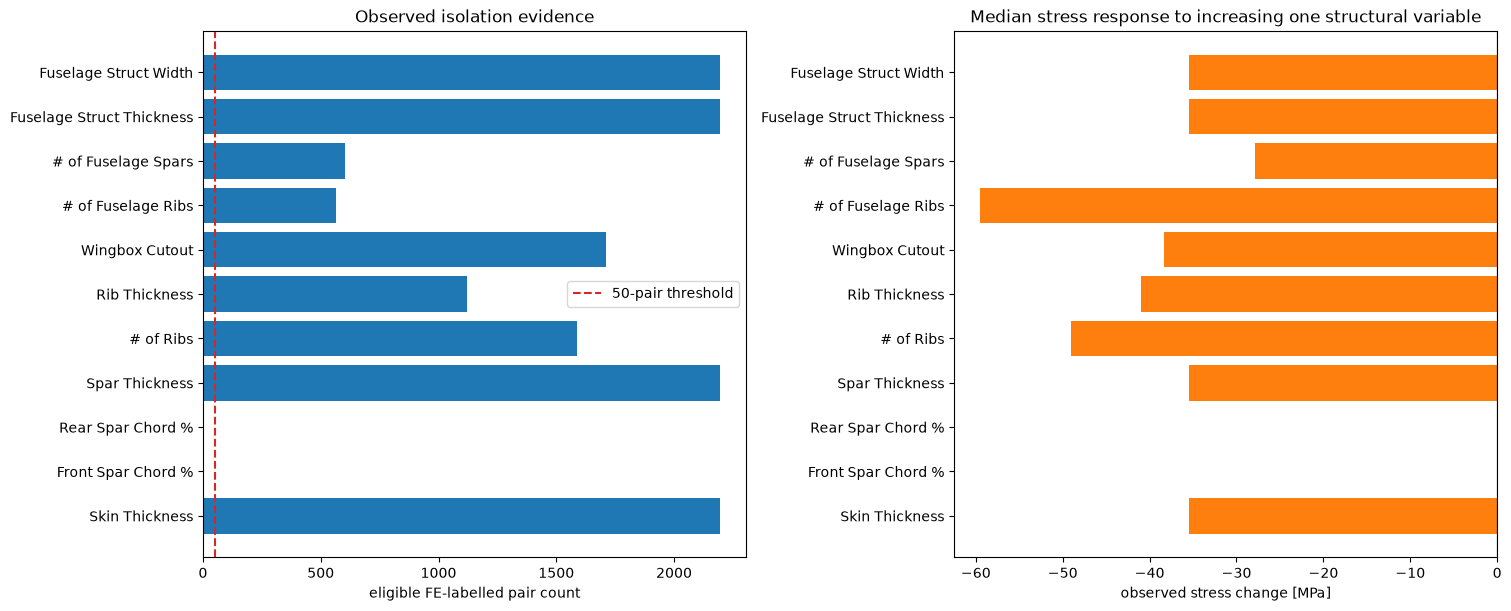

Wrote:
 - outputs/robustness_feasibility_transitions.csv
 - outputs/robustness_input_support.csv
 - outputs/robustness_matched_pair_effects.csv


In [7]:
plot_data = effects.set_index('variable').loc[STRUCTURAL_COLUMNS].copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
axes[0].barh(plot_data.index, plot_data['eligible_pair_count'], color=np.where(plot_data['supported'], 'tab:blue', 'tab:gray'))
axes[0].axvline(MIN_MATCHED_PAIRS, color='tab:red', linestyle='--', label=f'{MIN_MATCHED_PAIRS}-pair threshold')
axes[0].set(title='Observed isolation evidence', xlabel='eligible FE-labelled pair count')
axes[0].legend()
axes[1].barh(plot_data.index, plot_data['stress_mpa_increase_median'], color='tab:orange')
axes[1].axvline(0, color='black', linewidth=.8)
axes[1].set(title='Median stress response to increasing one structural variable', xlabel='observed stress change [MPa]')
plt.show()

print('Wrote:')
for path in sorted(OUTPUT_DIR.glob('robustness_*.csv')):
    print(' -', path.relative_to(ROOT))


## Interpreting results

- Use only rows marked `supported` to choose database-backed structural perturbation levels.
- Apply a level in both valid directions from a baseline design, clipping at documented bounds. For integer variables, use the valid integer/odd-integer step reported here.
- Treat a high feasibility-flip rate or a high volume-decrease rate as a warning, especially in the 0–25 MPa stress-margin cohort.
- Do not use the planform support ranges as evidence of a planform response. The direct L/D forward model can evaluate aerodynamic changes, but this FE database has no matched planform counterfactuals for structural stress or volume.
- For any optimizer-created continuous candidate, use these levels only as a screening envelope. Its changed FE responses require an independent evaluator or an exported-geometry structural solve.